Begin processing. Import required libraries.

In [35]:
# Import statements

import pandas as pd

# manage paths
from pathlib import Path
# plotting
from matplotlib import pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# dates
import datetime as dt
# numbers
import numpy as np
# Return errors iirc
from collections.abc import Callable
from contextlib import redirect_stdout
import traceback
# input output
import io
# sensitivity test
import itertools
# process images
from PIL import Image


from mrrpropy.raw_class import MRRProData
from mrrpropy.hexagram import plot_process_to_hexagram
from mrrpropy.plotting.processes import plot_fused_process_quicklook



Create useful defaults and accept inputs for layer, period, and a target time. _input, _debug, and _debug can be used for dev options. ARGS can be used to selectively render graphs (similar to running plots with arguments.)

In [36]:
# Setup/Init

# Paths
RAW_PATH = Path(r"C:\Projects\mrrpropy\tests\data\RAW\20241028_220000.nc")
OUTPUT_DIR = Path("C:/Projects/mrrpropy/tests/data/PRODUCTS/" + RAW_PATH.stem)
PRODUCT_PATH = Path(r"C:\Projects\mrrpropy\tests\data\PRODUCTS\20241028_220000_raprompro.nc")
gauss_path = Path("C:/Projects/mrrpropy/Workbench/assets/gaussian_splat_blob.svg")

ARGS = {
    "output_dir": OUTPUT_DIR,
    "only": "plot-column-process-scan",
}

_input = 1 # Control if you want to input the target time and layer range or just use defaults. 1 for input, 0 for defaults.
_bypass = 0
_debug = 0

# defaults 
PERIOD = (dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S"), dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S")+dt.timedelta(minutes=59))
TARGET_TIME = dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=30)
LAYER = (1000.0, 2000.0)  

# Define useful variables.
if _input == 1:
    try:
        PERIOD = tuple(dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=int(ts.strip())) for ts in input("Please input time range M, M ").split(","))
        TARGET_TIME = dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=int(input("Please input minute timestamp of target time. ")))
        LAYER = tuple(int(x) for x in input("Please input layer range in meters (e.g. [1000, 2000]): ").split(","))
    except:
        print(f"Error in input formatting. You entered (or left blank) {PERIOD}, {TARGET_TIME}, and {LAYER}, at least one of which was the wrong format.")
        
      
QUICKLOOK_PROCESSES = [
    "breakup",
    "growth_depletion",
    "growth_depletion_loss",
    "growth_depletion_gain",
    "activation",
    "evaporation",
    "growth",
]


Process raw file, or use the existing raw.

In [37]:
# Start by processing the RAW file.
# Load the raw file
mrr = MRRProData.from_file(RAW_PATH)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# build the product path using Path / (stem + suffix)
PRODUCT_PATH = OUTPUT_DIR / (RAW_PATH.stem + "_raprompro.nc")

if PRODUCT_PATH in OUTPUT_DIR.glob("*_raprompro.nc") and _debug == 0:
    print(f"Processed file already exists in {OUTPUT_DIR}. Skipping processing.")
    mrr.load_raprompro(PRODUCT_PATH)
else:
    # Process and save (pass OUTPUT_DIR as a Path)
    mrr.process_raprompro_optimized(save=True, output_dir=OUTPUT_DIR, save_dsd_3d=True, save_spe_3d=True)


Processed file already exists in C:\Projects\mrrpropy\tests\data\PRODUCTS\20241028_220000. Skipping processing.


Create useful class for the column scan process.

In [38]:
# Create the PlotContext class 

# This is useful--helps scan for context/classification. Might replace with gradient descent at some point.
class PlotContext:
    
    # Check that raw and processed files exist
    def __init__(self) -> None:
        if not RAW_PATH.exists():
            raise FileNotFoundError(f"Missing RAW fixture: {RAW_PATH}")
        if not PRODUCT_PATH.exists():
            raise FileNotFoundError(f"Missing RaProMPro product: {PRODUCT_PATH}")

        # Reload the MRRProData to ensure we have a clean state and the processed data is loaded.
        self.mrr = MRRProData.from_file(RAW_PATH)
        self.mrr.load_raprompro(PRODUCT_PATH)
        self._analysis_fixed = None
        self._classified_fixed = None
        self._scan_df = None

    # close mrr object
    def close(self) -> None:
        self.mrr.close()

    # Get target range from dataset.
    @property
    def target_range(self) -> float:
        ds = self.mrr.ds
        return float(ds["range"].values[ds.sizes["range"] // 2])

    # Process and analyze.
    @property
    def fixed_analysis(self):
        if self._analysis_fixed is None:
            self._analysis_fixed = self.mrr.rain_process_analyze(
                period=PERIOD,
                k=11,
                selection_mode="fixed_layer",
                z_bottom_m=LAYER[0],
                z_top_m=LAYER[1],
                ze_th=-5.0,
                min_points_trend=10,
                eps_q=0.01,
                rgb_q=0.02,
                vars_trend=("Dm", "Nw", "LWC"),
            )
        return self._analysis_fixed

    # Run classification on the fixed layer analysis.
    @property
    def fixed_classified(self):
        if self._classified_fixed is None:
            self._classified_fixed = self.mrr.classify_rain_process(
                analysis=self.fixed_analysis
            )
        return self._classified_fixed

    # Make a scanning dataframe.
    @property
    def scan_df(self) -> pd.DataFrame:
        if self._scan_df is None:
            self._scan_df = self.mrr.build_column_process_scan_dataframe(
                period=PERIOD,
                k=11,
                window_thickness_m=500.0,
                window_step_m=None,
                min_tau_strength=0.3,
            )
        return self._scan_df

    # Pick the first meaningful process label from the fixed layer classification.
    @property
    def representative_process(self) -> str:
        labels = self.fixed_classified["proc_label"].values.astype(str)
        process = next(
            (
                label
                for label in labels
                if label not in {"no_data", "unknown", "steady_or_weak"}
            ),
            None,
        )
        if process is not None:
            return str(process)
        fallback = next((label for label in labels if label != "no_data"), None)
        return str(fallback or "steady_or_weak")

    # Return up to two meaningful labels.
    @property
    def representative_processes(self) -> list[str]:
        labels = sorted(
            {
                label
                for label in self.fixed_classified["proc_label"].values.astype(str)
                if label not in {"no_data", "unknown", "steady_or_weak"}
            }
        )
        return labels[:2] if labels else [self.representative_process]



Next, make a function to save plots with correct names.

In [39]:
# Create the save function

# Save
def _save(fig, output_dir: Path, filename: str, _range: tuple) -> Path:
    # Make director if it does not exist, then save the figure.
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f"{RAW_PATH.stem}_{filename}_{'_'.join(str(dt.minute) for dt in _range)}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return path


We then make a dataframe from a scan.

In [40]:
# Make a dataframe from a scan.

# Use the scan to make a fused df (?)
def _fused_df_from_scan(scan_df: pd.DataFrame) -> pd.DataFrame:
    valid = scan_df.copy()
    valid["z_top_m"] = pd.to_numeric(valid["z_top_m"], errors="coerce")
    valid["z_bottom_m"] = pd.to_numeric(valid["z_bottom_m"], errors="coerce")
    valid = valid[valid["z_top_m"].gt(valid["z_bottom_m"])].copy()
    if valid.empty:
        return pd.DataFrame()

    plottable = valid[valid["proc_label"].astype(str).isin(QUICKLOOK_PROCESSES)].copy()
    source = plottable.iloc[0] if not plottable.empty else valid.iloc[0]
    time0 = pd.Timestamp(pd.to_datetime(source["time"]))
    label = str(source["proc_label"])
    if label not in QUICKLOOK_PROCESSES:
        label = QUICKLOOK_PROCESSES[-1]

    snap = valid[
        (valid["time"] == time0) & (valid["proc_label"].astype(str) == label)
    ].copy()
    if snap.empty:
        snap = pd.DataFrame([source])

    if "window_id" in snap.columns:
        snap = snap.sort_values("window_id", ascending=False)
    take = snap.head(3)

    return pd.DataFrame(
        {
            "time": [time0],
            "proc_label_fused": [label],
            "z_top_fused": [float(take["z_top_m"].max())],
            "z_bottom_fused": [float(take["z_bottom_m"].min())],
        }
    )



Define all graphs that will be used.

In [ ]:
# All graphs

# normal quicklook.
def quicklook_raw(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.quicklook(variable="Ze", source="raw", vmin=-10, vmax=40)
    return _save(fig, output_dir, "quicklook_raw_ze.png", PERIOD)

# *enhanced* quicklook.
def quicklook_raprompro(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.quicklook(variable="Ze", source="raprompro", vmin=-10, vmax=40)
    return _save(fig, output_dir, "quicklook_raprompro_ze.png", PERIOD)

# Plot a spectrum showing doppler velocity on x and spectrum [dB] on y.
def plot_spectrum(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_spectrum(
        TARGET_TIME,
        ctx.target_range,
        spectrum_var="spectrum_raw",
    )
    return _save(fig, output_dir, "plot_spectrum.png", PERIOD)

# Plot multiple spectra at different ranges.
def plot_spectra_by_range(ctx: PlotContext, output_dir: Path) -> Path:
    ranges = (
        ctx.mrr.ds["range"]
        .values[[5, ctx.mrr.ds.sizes["range"] // 2, -5]]
        .astype(float)
    )
    fig, _, _ = ctx.mrr.plot_spectra_by_range(TARGET_TIME, ranges)
    return _save(fig, output_dir, "plot_spectra_by_range.png", PERIOD)


# Plot velocity (x), range (y), and intensity (color).
def plot_spectrogram_raw(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_spectrogram(TARGET_TIME, spectrum_var="spectrum_raw")
    return _save(fig, output_dir, "plot_spectrogram_raw.png", PERIOD)

# Raprompro filters out some things, so plot that.
def plot_spectrogram_raprompro(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_spectrogram(TARGET_TIME, spectrum_var="spe_3D")
    return _save(fig, output_dir, "plot_spectrogram_raprompro.png", PERIOD)

# I don't know what this is but it looks cool.
def plot_dsdgram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_DSDgram(target_datetime=TARGET_TIME)
    return _save(fig, output_dir, "plot_dsdgram.png", PERIOD)

# Plot the droplet size distribution (DSD) as a function of range. Diameter (x) and Number (y, log)
def plot_dsd_by_range(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_DSD_by_range(
        TARGET_TIME,
        ranges=np.arange(3000, 4500, 250),
    )
    return _save(fig, output_dir, "plot_dsd_by_range.png", PERIOD)

# Plot the DSD by range in 3D. This isn't really useful.
def plot_dsd_by_range_3d(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_DSD_by_range_3d(
        TARGET_TIME,
        ranges=np.arange(3000, 4500, 100),
    )
    return _save(fig, output_dir, "plot_dsd_by_range_3d.png", PERIOD)

# Plot how microphysical properties (Dm, Nw, LWC) vary with height for the target time.
def plot_microphysical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_microphysical_properties_profiles(
        target_datetime=TARGET_TIME
    )
    return _save(fig, output_dir, "plot_microphysical_properties_profiles.png", PERIOD)

# I believe this plots each "process" event as a point on a plot showing the change in MIC_PRO
def plot_rain_process_2d(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_rain_process_in_layer_2D(
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        z="LWC",
        marker_size=100,
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_rain_process_in_layer_2d.png", PERIOD)

# I'm not sure what the difference between this and the previous one is.
def plot_event_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_event_scatter(
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        color="LWC",
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_event_scatter.png", PERIOD)

# Same here. Need more data points.
def plot_region_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_region_scatter(
        target_datetime=PERIOD,
        z_bottom_m=LAYER[0],
        z_top_m=LAYER[1],
        x="Dm",
        y="Nw",
        color="LWC",
        processes=ctx.representative_processes,
        classified=ctx.fixed_classified,
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_region_scatter.png", PERIOD)

# Same.
def plot_process_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_process_scatter(
        classified=ctx.fixed_classified,
        process=ctx.representative_process,
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        color="LWC",
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_process_scatter.png", PERIOD)

# This one looks broken. I need to understand events.
def plot_event_vertical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_event_vertical_percent_profiles(
        target_datetime=PERIOD,
        layer=LAYER,
        variables=("Dm", "Nw", "LWC"),
        figsize=(7, 6),
    )
    return _save(fig, output_dir, "plot_event_vertical_percent_profiles.png", PERIOD)

# Same here.
def plot_process_vertical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_process_vertical_percent_profiles(
        classified=ctx.fixed_classified,
        process=ctx.representative_process,
        target_datetime=PERIOD,
        layer=LAYER,
        variables=("Dm", "Nw", "LWC"),
        figsize=(7, 6),
    )
    return _save(fig, output_dir, "plot_process_vertical_percent_profiles.png", PERIOD)

# Plots each process on the hexagram using a colorbar to show time.
def plot_layer_hexagram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_rain_process_in_layer_hexagram(
        analysis=ctx.fixed_analysis,
        alpha_hexagram=0.5,
        cmap="viridis",
    )
    return _save(fig, output_dir, "plot_rain_process_in_layer_hexagram.png", PERIOD)

# I also don't understand this.
def plot_processes_evolution(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_processes_evolution(
        classified=ctx.fixed_classified,
        analysis=ctx.fixed_analysis,
        figsize=(14, 10),
        cmap="viridis",
        alpha_hexagram=0.5,
        markersize=40.0,
        line_width=0.8,
    )
    return _save(fig, output_dir, "plot_processes_evolution.png", PERIOD)

# Run classification on the events and plot the classified ones on the hexagram.
def plot_classified_hexagram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_classified_processes_on_hexagram(
        classified=ctx.fixed_classified,
        analysis=ctx.fixed_analysis,
        show_background=True,
        figsize=(14, 10),
        cmap="viridis",
        alpha_hexagram=0.25,
        markersize=70.0,
        line_width=0.8,
        legend_fontsize=14,
    )
    return _save(fig, output_dir, "plot_classified_processes_on_hexagram.png", PERIOD)

# My favorite! Show the processes. Run sensitivity testing on this and make one with different coloring.
def plot_column_process_scan(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _, _ = ctx.mrr.plot_column_process_scan(
        scan_df=ctx.scan_df,
        figsize=(10, 6),
        color_mode = "hexagram",
        marker="gaussian"
    )

    return _save(fig, output_dir, "plot_column_process_scan.png", PERIOD)

# Not sure what this is yet.
def plot_scan_scatter_compare(ctx: PlotContext, output_dir: Path) -> Path:
    selected = sorted(
        {
            label
            for label in pd.unique(ctx.scan_df["proc_label"].astype(str))
            if label not in {"unknown", "no_data", "steady_or_weak"}
        }
    )[:2]
    fig, _, _ = ctx.mrr.plot_scan_process_scatter_compare(
        scan_df=ctx.scan_df,
        processes=selected or None,
        show_centroids=True,
        figsize=(10, 8),
    )
    return _save(fig, output_dir, "plot_scan_process_scatter_compare.png", PERIOD)

# I *think* this is showing the processes overlaid on quicklook. If so it's what I need.
def plot_fused_quicklook(ctx: PlotContext, output_dir: Path) -> Path:
    fused_df = _fused_df_from_scan(ctx.scan_df)
    fig, _, _ = plot_fused_process_quicklook(
        ctx.scan_df,
        fused_df,
        processes=QUICKLOOK_PROCESSES,
        figsize=(10, 6),
    )
    return _save(fig, output_dir, "plot_fused_process_quicklook.png", PERIOD)

# This shows the regions on the hexagram for a given process. See the powerpoint for more.
def plot_hexagram_process(ctx: PlotContext, output_dir: Path) -> Path:
    fig = plot_process_to_hexagram(
        process="activation",
        k=11,
        tol_center=0.15,
        crop_to_process=False,
    )
    return _save(fig, output_dir, "plot_process_to_hexagram.png", PERIOD)


We need to make the graphs referencable so we can selectively enable or disable some.

In [42]:
# Update this whenever you add new graphs.

PLOTS: dict[str, Callable[[PlotContext, Path], Path]] = {
    "quicklook-raw": quicklook_raw,
    "quicklook-raprompro": quicklook_raprompro,
    "plot-spectrum": plot_spectrum,
    "plot-spectra-by-range": plot_spectra_by_range,
    "plot-spectrogram-raw": plot_spectrogram_raw,
    "plot-spectrogram-raprompro": plot_spectrogram_raprompro,
    "plot-dsdgram": plot_dsdgram,
    "plot-dsd-by-range": plot_dsd_by_range,
    "plot-dsd-by-range-3d": plot_dsd_by_range_3d,
    "plot-microphysical-profiles": plot_microphysical_profiles,
    "plot-rain-process-2d": plot_rain_process_2d,
    "plot-event-scatter": plot_event_scatter,
    "plot-region-scatter": plot_region_scatter,
    "plot-process-scatter": plot_process_scatter,
    "plot-event-vertical-profiles": plot_event_vertical_profiles,
    "plot-process-vertical-profiles": plot_process_vertical_profiles,
    "plot-layer-hexagram": plot_layer_hexagram,
    "plot-processes-evolution": plot_processes_evolution,
    "plot-classified-hexagram": plot_classified_hexagram,
    "plot-column-process-scan": plot_column_process_scan,
    "plot-scan-scatter-compare": plot_scan_scatter_compare,
    "plot-fused-quicklook": plot_fused_quicklook,
    "plot-hexagram-process": plot_hexagram_process,
}

Run sensitivity testing on column scan.

In [43]:
# Sensitivity testing with plot grid
def sensitivity_test_plot_column_process_scan(ctx, output_dir, lim, period, raw_stem):

    # Define sensitivity test parameters - vary window thickness and tau strength. 
    sensitivity_params = {
        "window_thickness_m": [300.0, 500.0, 1000.0],
        "min_tau_strength": [0.3, 0.5, 0.7],
    }
    
    # Generate combinations for testing
    param_combinations = list(
        itertools.product(
            sensitivity_params["window_thickness_m"],
            sensitivity_params["min_tau_strength"],
        )
    )
    
    # Create grid dimensions
    n_plots = len(param_combinations)
    n_cols = len(sensitivity_params["window_thickness_m"])
    n_rows = len(sensitivity_params["min_tau_strength"])

    
    # Create figure with subplots
    fig_grid, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    # Run sensitivity tests
    for idx, (thickness, tau_strength) in enumerate(param_combinations):
        print(f"[{idx+1}/{n_plots}] thickness={thickness}m, tau_strength={tau_strength}")
        
        scan_df_test = ctx.mrr.build_column_process_scan_dataframe(
            period=period,
            k=11,
            window_thickness_m=thickness,
            window_step_m=None,
            min_tau_strength=tau_strength,
        )
        
        fig_individual, _ = ctx.mrr.plot_column_process_scan(
            scan_df=scan_df_test,
            figsize=(8, 5),
        )
    
        # Convert to image, avoiding collection/figure conflicts
        buf = io.BytesIO()
        fig_individual.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        img = Image.open(buf)
        
        ax_grid = axes_flat[idx]
        ax_grid.imshow(img)
        ax_grid.set_title(f"w={thickness}m, τ={tau_strength}", fontsize=10, fontweight="bold")
        ax_grid.axis('off')
        
        plt.close(fig_individual)
    

    for idx in range(n_plots, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    
    # Add titles and save
    fig_grid.suptitle("Sensitivity Testing: plot_column_process_scan", fontsize=14, fontweight="bold")
    fig_grid.tight_layout()
    
    # Save the grid
    output_dir.mkdir(parents=True, exist_ok=True)
    grid_path = output_dir / (raw_stem + "_sensitivity_test_grid.png")
    fig_grid.savefig(grid_path, dpi=140, bbox_inches='tight')
    print(f"Saved: {grid_path}\n")
    
    # Show in interactive mode
    plt.show()

Finally, run this to actually run the program.

In [53]:
ctx = PlotContext()
print(ctx)

In [52]:
# Run everything.
def main() -> None:
    selected = (
        [name.strip() for name in ARGS["only"].split(",") if name.strip()]
        if ARGS["only"]
        else list(PLOTS)
    )
    ctx = PlotContext()
    if _bypass == 0:
        try:
            for name in selected:
                try:
                    with redirect_stdout(io.StringIO()):
                        path = PLOTS[name](ctx, ARGS["output_dir"])
                except Exception as exc:
                    print(f"{name}: ERROR: {exc}")
                    print(traceback.format_exc())
                else:
                    print(f"{name}: {path}")
        finally:
            ctx.close()
    else:
        sensitivity_test_plot_column_process_scan(ctx, OUTPUT_DIR, (0, 5000), PERIOD, RAW_PATH.stem)
        ctx.close()
    

if __name__ == "__main__":
    main()


plot-column-process-scan: C:\Projects\mrrpropy\tests\data\PRODUCTS\20241028_220000\20241028_220000_plot_column_process_scan.png_20_26.png


C:\Projects\mrrpropy\mrrpropy\plotting\processes.py:1093: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter = ax.scatter(


This is if you want to see the data quickly.

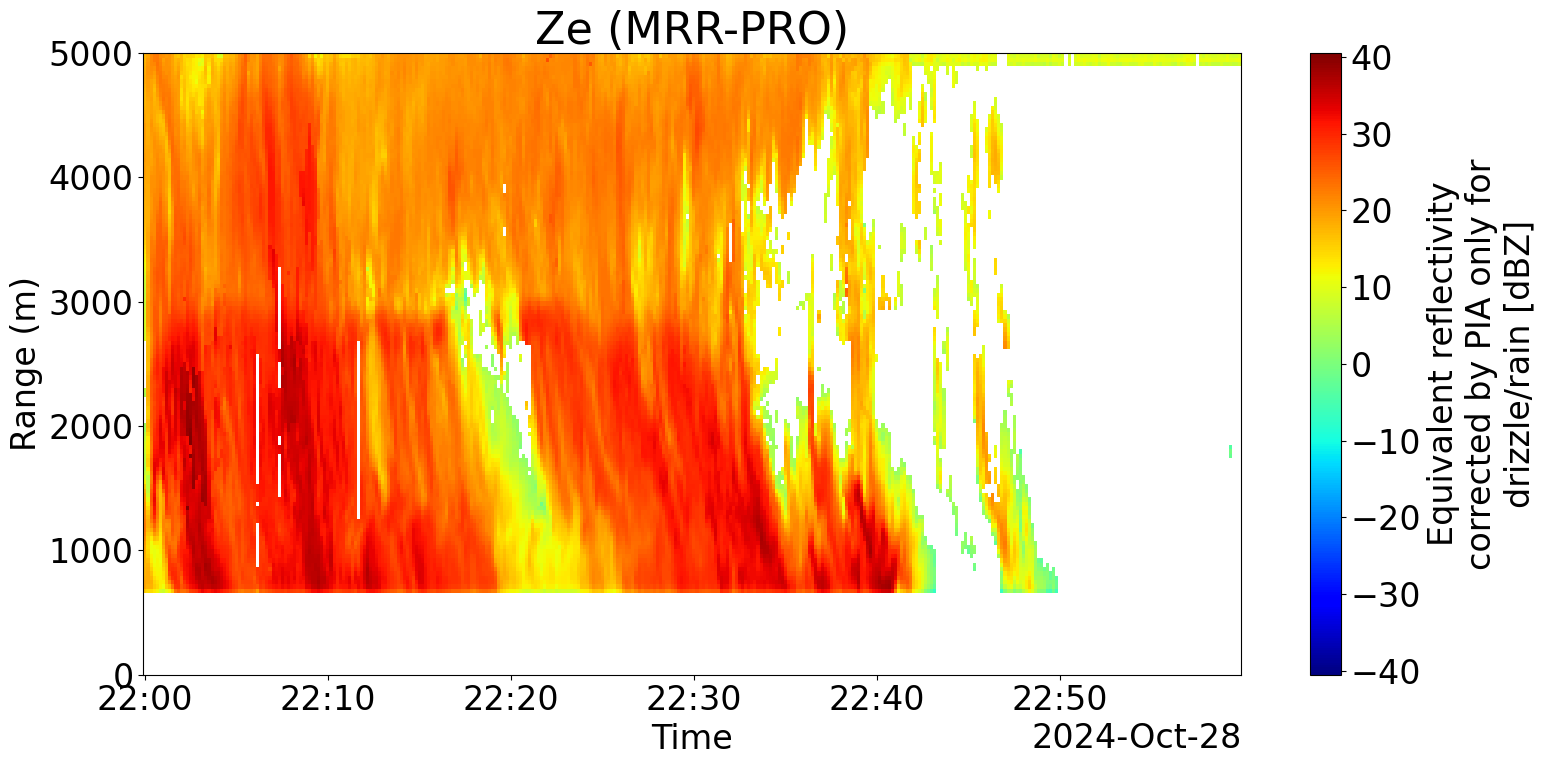

In [45]:
fig, ax = mrr.quicklook()
ax.plot()
ax.set_ylim(0, 5000)
plt.show()  